# Description
Calculation of the number of passes using real breadcrumbs. Finished on May 18th, 2026. It is the first version it can count by boundary cell. The grid is done by rectangles

In [106]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [107]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.geometry import LineString, Point
from shapely.affinity import rotate
import numpy as np
import pandas as pd
import geopandas as gpd
import warnings
from inc import *
from shapely.ops import polygonize, unary_union

# Configuration

In [108]:
tol_deg  = 5
street_length = 10
sampling_distance = 10
dx = 1            # Thickness of each vertical bar
angles = np.arange(0, 190, 10)

# Query the surveys

In [109]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[700]].copy()
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')

l = 0
surveys = segments['SurveyId'].unique()
#survey = segments[segments['SurveyId'] == surveys[l]]
survey = segments
survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)
survey_gdf = gpd.GeoDataFrame(survey, geometry = 'Breadcrumb_wkt', crs = 'EPSG:4326')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)

# Algorithm starts here
## Prepare the surveys

In [110]:
# Compute the union of the survey geometries and simplify the result
survey_union = survey_gdf.unary_union.simplify(2)  # Adjust tolerance 1.0 as needed

# Create a GeoDataFrame from the union
survey_union_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union]},
    crs=survey_gdf.crs
)

# Make an offset of 10 (buffer by 10 units)
survey_union_offset_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union.buffer(street_length/2, cap_style=2)]},
    crs=survey_gdf.crs,
    geometry='geometry'
)

In [111]:
# Get the center as the midpoint of the bounds (average of min/max x/y)
minx, miny, maxx, maxy = survey_union_offset_gdf.total_bounds
center = Point((minx + maxx) / 2, (miny + maxy) / 2)
print("Center of the bounds:", center)

# Shift the survey_union_offset_gdf geometry so that the centroid is at (0, 0)
survey_union_offset_gdf['geometry'] = survey_union_offset_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)

Center of the bounds: POINT (508123.072905 5914381.83584)


In [112]:
survey_gdf['geometry'] = survey_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)
# Generate 

In [160]:
survey_gdf

,ReportId,SurveyId,Breadcrumb,Order,Breadcrumb_wkt,geometry
0,FC2E76DB-07A3-C4E4-A3AC-3A205F4F5596,6545520C-F6E1-4326-C9D1-3A204E4F5443,"LINESTRING (-2.88091873 53.3778739, -2.8811740...",18,"LINESTRING (507921.639 5914313.833, 507904.655...","LINESTRING (-201.434 -68.003, -218.417 -67.459..."
1,FC2E76DB-07A3-C4E4-A3AC-3A205F4F5596,6545520C-F6E1-4326-C9D1-3A204E4F5443,"LINESTRING (-2.88867847 53.38350626, -2.888493...",149,"LINESTRING (507404.461 5914939.593, 507416.793...","LINESTRING (-718.612 557.757, -706.279 519.531..."
2,FC2E76DB-07A3-C4E4-A3AC-3A205F4F5596,6545520C-F6E1-4326-C9D1-3A204E4F5443,"LINESTRING (-2.87301898 53.37745443, -2.871450...",79,"LINESTRING (508447.237 5914268.073, 508551.500...","LINESTRING (324.164 -113.763, 428.427 -58.154,..."
3,FC2E76DB-07A3-C4E4-A3AC-3A205F4F5596,6545520C-F6E1-4326-C9D1-3A204E4F5443,"LINESTRING (-2.87518775 53.37791082, -2.875839...",71,"LINESTRING (508302.873 5914318.591, 508259.391...","LINESTRING (179.801 -63.245, 136.318 18.306, 1..."
4,FC2E76DB-07A3-C4E4-A3AC-3A205F4F5596,6545520C-F6E1-4326-C9D1-3A204E4F5443,"LINESTRING (-2.87792239 53.38593709, -2.878053...",185,"LINESTRING (508119.430 5915211.190, 508110.725...","LINESTRING (-3.643 829.354, -12.348 827.057, -..."
...,...,...,...,...,...,...
762,FC2E76DB-07A3-C4E4-A3AC-3A205F4F5596,0D1AE50B-E353-9D66-9942-3A2053B5F0D4,"LINESTRING (-2.88392266 53.38732095, -2.884048...",179,"LINESTRING (507720.100 5915364.477, 507711.733...","LINESTRING (-402.973 982.641, -411.340 975.940..."
763,FC2E76DB-07A3-C4E4-A3AC-3A205F4F5596,0D1AE50B-E353-9D66-9942-3A2053B5F0D4,"LINESTRING (-2.86681469 53.37518595, -2.866969...",97,"LINESTRING (508860.439 5914016.459, 508850.118...","LINESTRING (737.366 -365.377, 727.045 -338.801..."
764,FC2E76DB-07A3-C4E4-A3AC-3A205F4F5596,0D1AE50B-E353-9D66-9942-3A2053B5F0D4,"LINESTRING (-2.87394175 53.38133047, -2.873175...",88,"LINESTRING (508385.089 5914699.169, 508436.283...","LINESTRING (262.016 317.333, 313.210 206.943, ..."
765,FC2E76DB-07A3-C4E4-A3AC-3A205F4F5596,0D1AE50B-E353-9D66-9942-3A2053B5F0D4,"LINESTRING (-2.86327518 53.37019019, -2.863822...",256,"LINESTRING (509096.977 5913461.133, 509060.598...","LINESTRING (973.904 -920.703, 937.525 -928.092..."


/tmp/ipykernel_9111/3853611118.py:4: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


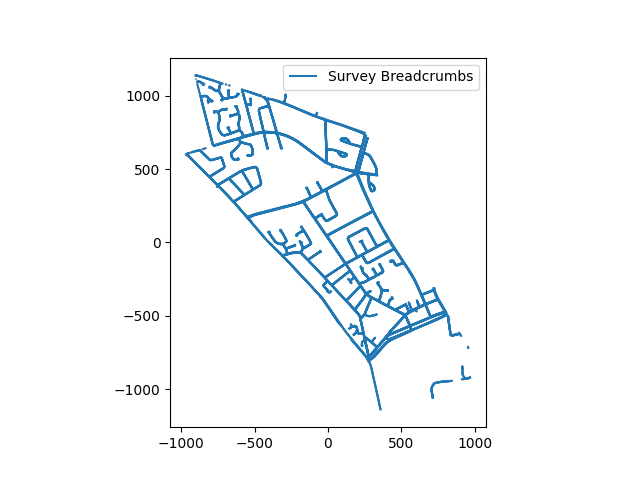

In [133]:
fig,ax = plt.subplots()
survey_gdf.plot(ax=ax, label='Survey Breadcrumbs')
survey_union_offset_gdf.plot(ax=ax, color='red', alpha=0.5, label='Street')
ax.legend()

# Generate the grid

In [115]:
output_gdf = gpd.GeoDataFrame()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for angle in angles:
            #print(f'Processing angle: {angle}')
            # Parameters for evenly spaced thin vertical rectangles (grid "bars")
            bounds = survey_union_offset_gdf.total_bounds
            min_x, min_y, max_x, max_y = map(float, bounds)  # Ensure cast to float
            r_x = np.sqrt(max_x**2 + max_y**2)
            r_y = np.sqrt(min_x**2 + min_y**2)

            # Compute number of columns safely and cast to int
            num_cols = int(np.floor((2*r_x) / sampling_distance)) + 1

            # Compute bar center x-positions
            x_centers = np.linspace(-r_x, r_x, num=num_cols)

            # For each center, form a thin rectangle
            vertical_bars = [
                Polygon([
                    (x - dx/2, min_y),
                    (x + dx/2, min_y),
                    (x + dx/2, max_y),
                    (x - dx/2, max_y)
                ])
                for x in x_centers
            ]

           # Define the vector
            vec = np.array([1,0])
            ortho_vec = np.array([0,1])
            # Define a rotation angle in radians (example: 45 degrees)
            theta = np.deg2rad(angle)
            rotation_matrix = np.array([
                [np.cos(theta), -np.sin(theta)],
                [np.sin(theta), np.cos(theta)]
            ])

            # Rotate the vector by the rotation matrix
            rotated_vec = rotation_matrix @ vec
            ortho_vec = rotation_matrix @ ortho_vec

            # Rotate the grid lines accordingly
            vertical_bars_r = [rotate(bar, angle=angle, origin=(0,0)) for bar in vertical_bars]
            grid_lines_gdf_r = gpd.GeoDataFrame({'geometry': vertical_bars_r}, crs=utm_crs, geometry='geometry')
            grid_lines_gdf_r['grid_idx'] = grid_lines_gdf_r.index

            #Create the intersection of the grid with the survey offset
            intersection_gdf = gpd.overlay(
                grid_lines_gdf_r, 
                survey_union_offset_gdf, 
                how='intersection', 
                keep_geom_type=False
            )
            intersection_gdf = intersection_gdf.explode(index_parts=True)
            intersection_gdf.reset_index(drop=True, inplace=True)
            intersection_gdf.set_geometry('geometry', inplace=True)

            try:
                #Get the bottom points of the intersected rectamgles
                intersection_gdf['bottom_points'] = intersection_gdf['geometry'].apply(get_bottom_points)
            except Exception as e:
                print(f'No bottom points for angle {angle}')
                print(intersection_gdf['geometry'])
                print(e)

            # Get the unit vector along the [1,0] direction or the rotated version
            intersection_gdf['unit_vector'] = intersection_gdf['bottom_points'].apply(safe_unit_vector)

            # Get teh angle between the unit vector and the rotated vector
            intersection_gdf['angle'] = intersection_gdf['unit_vector'].apply(lambda vec: angle_between_vectors(vec, rotated_vec=rotated_vec))

            # Get only those lines which are aligned with the rotated vector
            right_angles = intersection_gdf[np.isclose(intersection_gdf['angle'], 0, atol=tol_deg)]
            if len(right_angles) > 0:
                #print('There is a right angle')
                #Get the cell boundaries
                right_angles['cell_boundary'] = right_angles.apply(lambda row: get_line_from_angle(row, ortho_vec), axis=1)

                #Rename the grid_idx to include the angle
                right_angles['grid_idx'] = right_angles.apply(lambda row: f"{row['grid_idx']}_{angle}", axis=1)
                right_angles.reset_index(drop=True)
                output_gdf = pd.concat([output_gdf, right_angles])

# Remove entries whose cell_boundary length > 1 std above the mean
lengths = output_gdf.cell_boundary.length
mean_length = lengths.mean()
std_length = lengths.std()
filtered_output_gdf = output_gdf[lengths <= (mean_length + std_length/2)]


#Remove all the intersecting 
#Create the cells
geom = survey_union_offset_gdf.iloc[0].geometry

# All grid lines as one noded multiline (tweak attribute if your geometry column differs)
lines = [getattr(row, "cell_boundary") for row in filtered_output_gdf.itertuples()]
splitters = unary_union(lines)
network = unary_union([geom.boundary, splitters])
cell_polys = [
    poly
    for poly in polygonize(network)
    if geom.contains(poly.representative_point())
]
print(len(lines), "splitters ->", len(cell_polys), "cells")
cell_gdf = gpd.GeoDataFrame({'geometry': cell_polys}, crs=survey_union_offset_gdf.crs)
cell_gdf = cell_gdf.reset_index().rename(columns={'index': 'cell_idx'})


2105 splitters -> 2259 cells


## Count the intersections by cell

In [116]:
# For each cell, create an inner offset to prevent bad counts
cell_offset_gdf = gpd.GeoDataFrame(geometry=cell_gdf.buffer(-0.1).explode(index_parts=False), crs=cell_gdf.crs)
cell_boundaries_gdf = gpd.GeoDataFrame(geometry=cell_offset_gdf.boundary.explode(), crs=cell_offset_gdf.crs)

/tmp/ipykernel_9111/1053509735.py:3: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  cell_boundaries_gdf = gpd.GeoDataFrame(geometry=cell_offset_gdf.boundary.explode(), crs=cell_offset_gdf.crs)


In [117]:

#For each cell, partition the polygon into segments along its boundary lines using exterior coordinates. This will help us to get the nummber of boundaries
segment_list = []
for poly in cell_offset_gdf.geometry:
    coords = list(poly.exterior.coords)
    for i in range(len(coords) - 1):
        seg = LineString([coords[i], coords[i+1]])
        segment_list.append(seg)

partitioned_gdf = gpd.GeoDataFrame(geometry=segment_list, crs=cell_offset_gdf.crs)

#Get the intersections of the surveys with the boundaries
points = gpd.GeoDataFrame(
    gpd.overlay(survey_gdf, cell_boundaries_gdf, how='intersection', keep_geom_type=False).explode(),
    crs=survey_gdf.crs
)
points = points.set_geometry('geometry')
points_buffer = gpd.GeoDataFrame(geometry=points.buffer(0.05), crs=points.crs)

#Get the boundaries that intersect with the survey
points_buffer.reset_index(drop=True, inplace=True)
boundaries = gpd.sjoin(points_buffer, partitioned_gdf, how='right', predicate='intersects')


/tmp/ipykernel_9111/336621587.py:13: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  gpd.overlay(survey_gdf, cell_boundaries_gdf, how='intersection', keep_geom_type=False).explode(),


In [118]:
#Get the boundaries that intersect with the survey
points_buffer.reset_index(drop=True, inplace=True)
boundaries = gpd.sjoin(points_buffer, partitioned_gdf, how='right', predicate='intersects')
# Fix: Only cast to int if value is finite (not NA/inf) to avoid IntCastingNaNError
if boundaries['index_left'].notnull().all():
    boundaries['index_left'] = boundaries['index_left'].astype(int)
else:
    # Fill NA with a placeholder (e.g., -1) before casting, or just keep NA if that's acceptable
    boundaries['index_left'] = boundaries['index_left'].fillna(-1).astype(int)
    # Drop rows where index_left == -1
boundaries = boundaries[boundaries['index_left'] != -1]
boundaries.rename(columns={'index_left': 'points_idx'}, inplace=True)
# Get unique geometries from 'boundaries' and put in a GeoDataFrame
unique_geoms = boundaries['geometry'].unique()
unique_gdf = gpd.GeoDataFrame(geometry=list(unique_geoms), crs=boundaries.crs)
unique_gdf.reset_index(drop=True, inplace=True)
joined_gdf_unique = gpd.sjoin(unique_gdf, cell_gdf, how='right', predicate='intersects')
boundary_counts = joined_gdf_unique.groupby('cell_idx').size().reset_index(name='boundaries')

# Get the number of intersections per cell
joined_gdf = gpd.sjoin(points, cell_gdf, how='left', predicate='intersects')
# Get intersection counts by cell
intersection_counts = joined_gdf.groupby('cell_idx').size().reset_index(name='intersections')
intersection_boundaties = intersection_counts.merge(boundary_counts, left_on='cell_idx', right_on='cell_idx', how='left')

#Get the output
cell_summary = cell_gdf.merge(intersection_boundaties, left_on='cell_idx', right_on='cell_idx', how='left')
cell_summary['passes'] = cell_summary['intersections'] / cell_summary['boundaries']

/tmp/ipykernel_9111/575504383.py:4: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axa.legend()


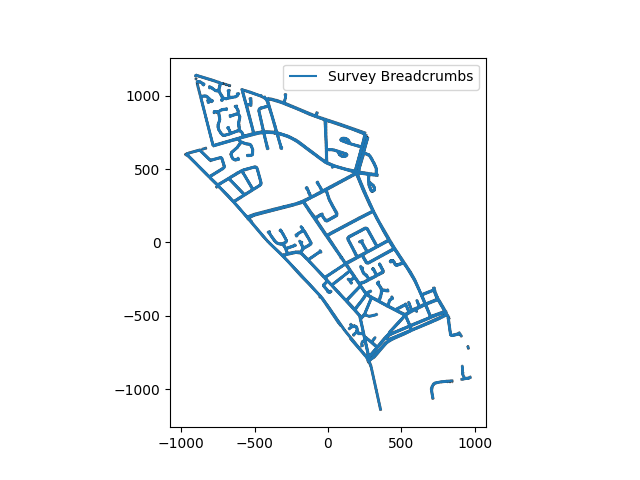

In [139]:
fig,axa = plt.subplots()
cell_gdf.plot(edgecolor='black', facecolor='none', alpha=0.5, ax=axa, label='Grid Cells')
survey_gdf.plot(ax=axa, label='Survey Breadcrumbs')
axa.legend()

In [119]:
# Use geopandas's dissolve to aggregate geometries by the 'passes' column
# This will produce a GeoDataFrame with one row per unique 'passes' value, with multipolygons where appropriate.

# Create a new GeoDataFrame with necessary columns
cell_info_nonan = cell_summary.dropna(subset=['passes']).copy()

dissolved = cell_info_nonan.dissolve(by='passes')

# Ensure the dissolved result is a GeoDataFrame indexed by 'passes'
aggregated_cells_by_pass_gdf = dissolved.reset_index()[['passes', 'geometry']]

/tmp/ipykernel_9111/1960337944.py:7: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


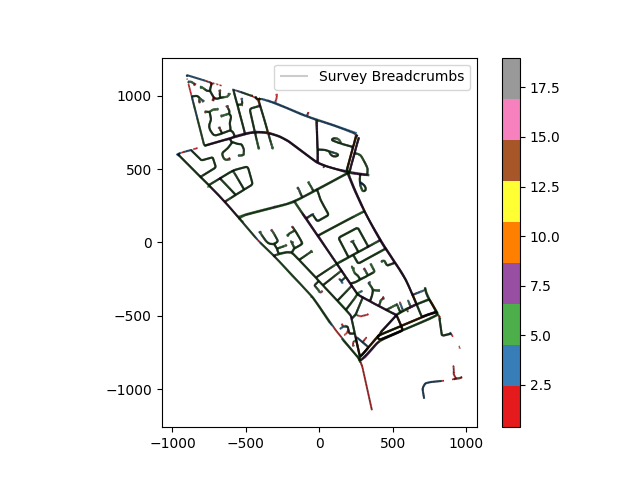

In [151]:
fig, ax = plt.subplots()
plot = cell_summary.plot(column='passes', cmap='Set1', ax=ax, legend=True, label='Number of passes')
survey_gdf.plot(ax=ax, label='Survey Breadcrumbs', color='black', alpha=0.2)
# Set title for colorbar
if plot.get_legend() is not None and hasattr(plot.get_legend(), 'set_title'):
    plot.get_legend().set_title('number of passes')
ax.legend()

In [120]:
aggregated_cells_by_pass_gdf['geometry'] = aggregated_cells_by_pass_gdf.translate(xoff=center.x, yoff=center.y)

In [156]:
survey_4326 = survey_gdf.copy()

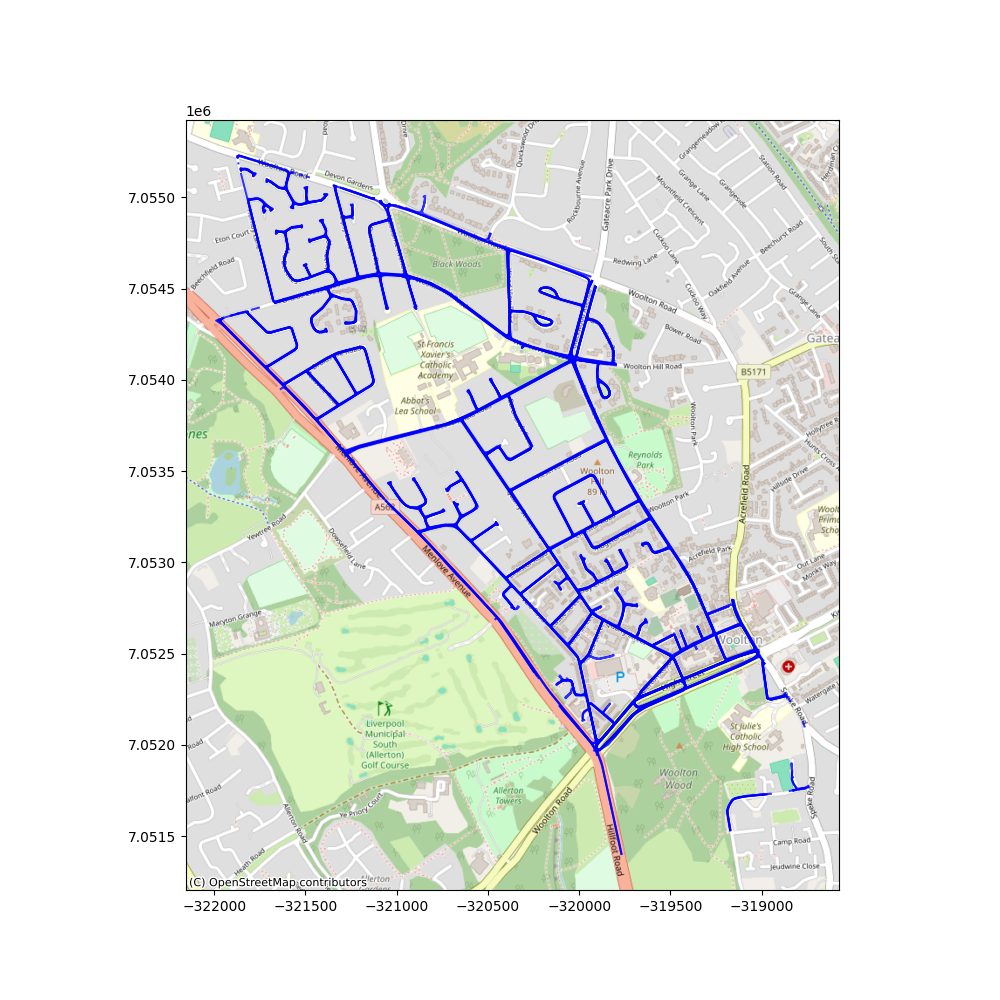

In [159]:
import contextily as ctx

# Project to Web Mercator for plotting with basemap
survey_webmerc = survey_4326.set_geometry('Breadcrumb_wkt').to_crs('EPSG:3857')
ax = survey_webmerc.plot(figsize=(10, 10), alpha=0.8, color='blue')
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


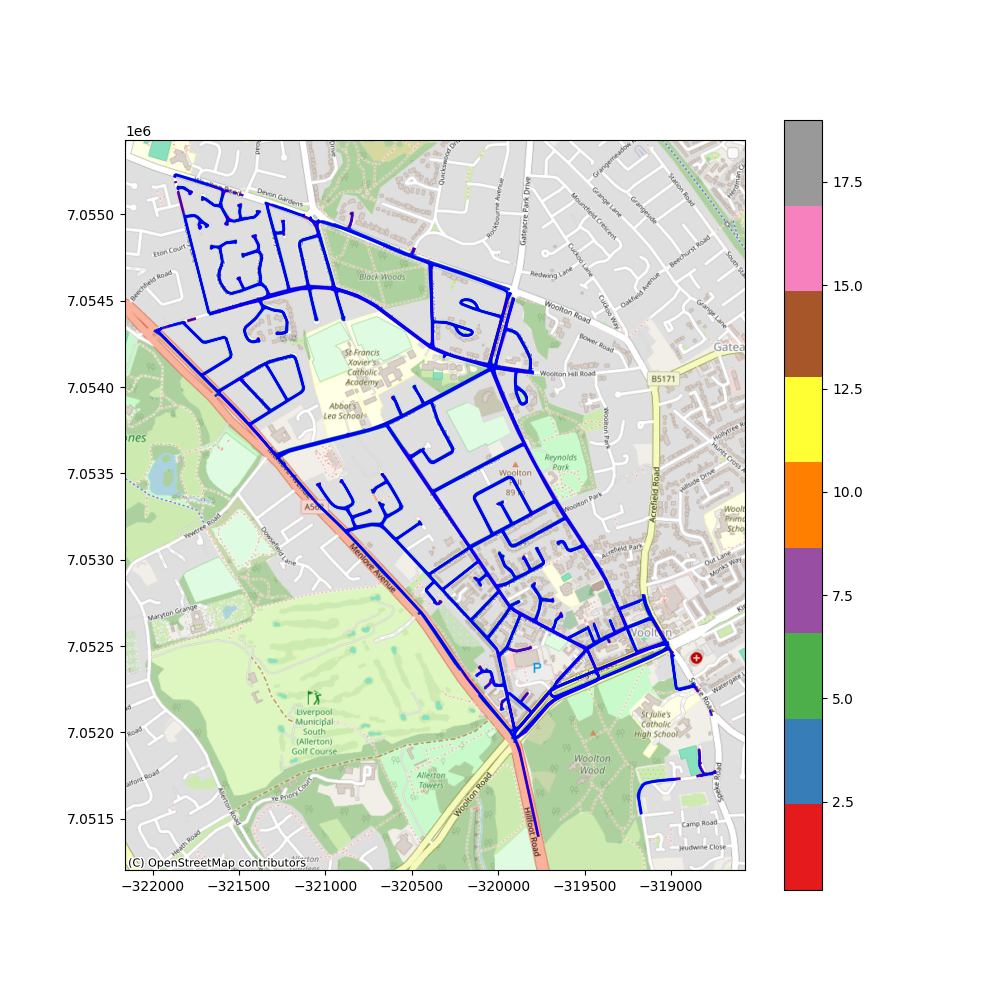

In [167]:
agg = aggregated_cells_by_pass_gdf.to_crs('EPSG:3857')
import contextily as ctx

ax = survey_webmerc.plot(figsize=(10, 10), alpha=0.8, color='blue')
ax = agg.plot(ax = ax, figsize=(10, 10), column='passes', cmap='Set1', legend=True)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.legend()

In [165]:
cell_summary['passes'].value_counts()

passes
6.000000     1044
8.000000      225
4.000000      143
7.000000      137
2.000000      106
5.000000      105
9.000000       49
1.000000       44
3.000000       30
10.000000      21
17.000000      15
11.000000      14
6.666667       14
7.333333       11
3.500000        9
3.333333        9
4.500000        9
2.500000        7
4.666667        7
15.000000       6
13.000000       5
5.333333        4
5.500000        4
1.500000        4
8.666667        4
2.333333        4
2.666667        4
3.666667        2
12.666667       2
11.333333       2
0.625000        2
6.500000        2
0.500000        2
0.882353        1
0.842105        1
0.750000        1
1.111111        1
0.933333        1
0.705882        1
7.500000        1
19.000000       1
0.833333        1
1.333333        1
1.052632        1
0.666667        1
5.222222        1
6.571429        1
5.833333        1
0.909091        1
1.066667        1
0.363636        1
0.533333        1
0.941176        1
0.571429        1
Name: count, dtype: i